# Exploration des données — Aquifer Petrignano

## Objectif de ce notebook

Ce notebook constitue la **première étape** de notre projet de PFE.  
Avant de construire un modèle, avant de coder quoi que ce soit, on doit **comprendre nos données**.


### Source des données

- **Dataset** : Acea Smart Water Analytics (Kaggle)
- **Fichier** : `Aquifer_Petrignano.csv`
- **Contexte** : Mesures journalières d'un aquifère en Ombrie (Italie centrale)
- **Période** : 2006 - 2020

## Étape 1 : Chargement des données

On utilise la bibliothèque **Pandas** pour lire le fichier CSV.  

In [1]:
import pandas as pd

# Charger le fichier CSV dans un DataFrame
df = pd.read_csv('../data/raw/Nappe_Petrignano.csv')

# Afficher les dimensions
print(f"Notre dataset contient :")
print(f"  → {df.shape[0]} lignes (= jours de mesures)")
print(f"  → {df.shape[1]} colonnes (= variables mesurées)")

Notre dataset contient :
  → 5223 lignes (= jours de mesures)
  → 8 colonnes (= variables mesurées)


## Étape 3 : Valeurs manquantes

In [2]:
# Compter les valeurs manquantes par colonne
missing = pd.DataFrame({
    'Valeurs manquantes': df.isnull().sum(),
    'Pourcentage (%)': (df.isnull().sum() / len(df) * 100).round(1)
})

# Trier du plus de manquantes au moins
missing = missing.sort_values('Pourcentage (%)', ascending=False)

print("=== Valeurs manquantes par colonne ===\n")
print(missing.to_string())
print(f"\n→ Total de lignes dans le dataset : {len(df)}")

=== Valeurs manquantes par colonne ===

                                      Valeurs manquantes  Pourcentage (%)
Rainfall_Bastia_Umbra                               1024             19.6
Hydrometry_Fiume_Chiascio_Petrignano                1024             19.6
Temperature_Petrignano                              1024             19.6
Temperature_Bastia_Umbra                            1024             19.6
Volume_C10_Petrignano                                198              3.8
Depth_to_Groundwater_P24                              55              1.1
Depth_to_Groundwater_P25                              39              0.7
Date                                                   0              0.0

→ Total de lignes dans le dataset : 5223


## Étape 4 : Detéction des trous

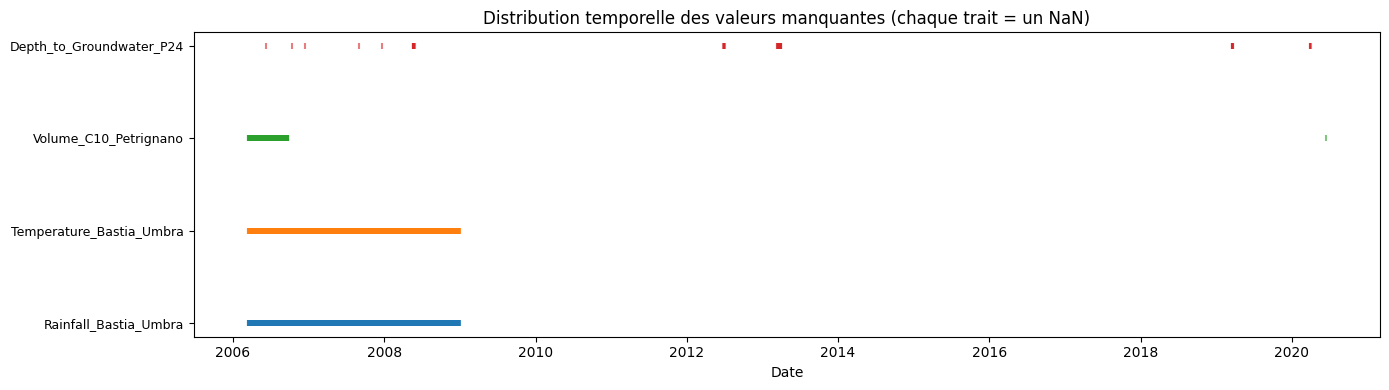

→ Figure sauvegardée dans data/processed/


In [3]:
import matplotlib.pyplot as plt

# Convertir la colonne Date en format datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Créer une figure qui montre les NaN dans le temps
fig, ax = plt.subplots(figsize=(14, 4))

# Pour chaque colonne, on trace un trait là où il y a un NaN
columns_to_check = [
    'Rainfall_Bastia_Umbra',
    'Temperature_Bastia_Umbra', 
    'Volume_C10_Petrignano',
    'Depth_to_Groundwater_P24'
]

for i, col in enumerate(columns_to_check):
    # Trouver les dates où la valeur est manquante
    missing_dates = df[df[col].isnull()]['Date']
    ax.scatter(missing_dates, [i] * len(missing_dates), 
              marker='|', s=20, label=col, alpha=0.6)

ax.set_yticks(range(len(columns_to_check)))
ax.set_yticklabels(columns_to_check, fontsize=9)
ax.set_xlabel('Date')
ax.set_title('Distribution temporelle des valeurs manquantes (chaque trait = un NaN)')
plt.tight_layout()

# Sauvegarder pour le rapport
plt.savefig('../data/processed/1_fig_valeurs_manquantes.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Étape 5 : Statistiques descriptives

In [4]:
# Statistiques descriptives de toutes les colonnes numériques
stats = df.describe().round(2)

print("=== Statistiques descriptives ===\n")
print(stats.to_string())

=== Statistiques descriptives ===

                      Date  Rainfall_Bastia_Umbra  Depth_to_Groundwater_P24  Depth_to_Groundwater_P25  Temperature_Bastia_Umbra  Temperature_Petrignano  Volume_C10_Petrignano  Hydrometry_Fiume_Chiascio_Petrignano
count                 5223                4199.00                   5168.00                   5184.00                   4199.00                 4199.00                5025.00                               4199.00
mean   2013-05-07 00:00:00                   1.56                    -26.26                    -25.69                     15.03                   13.74              -29043.30                                  2.37
min    2006-03-14 00:00:00                   0.00                    -34.47                    -33.71                     -3.70                   -4.20              -45544.90                                  0.00
25%    2009-10-09 12:00:00                   0.00                    -28.25                    -27.62            

## Étape 6a : Évolution du niveau piézométrique dans le temps

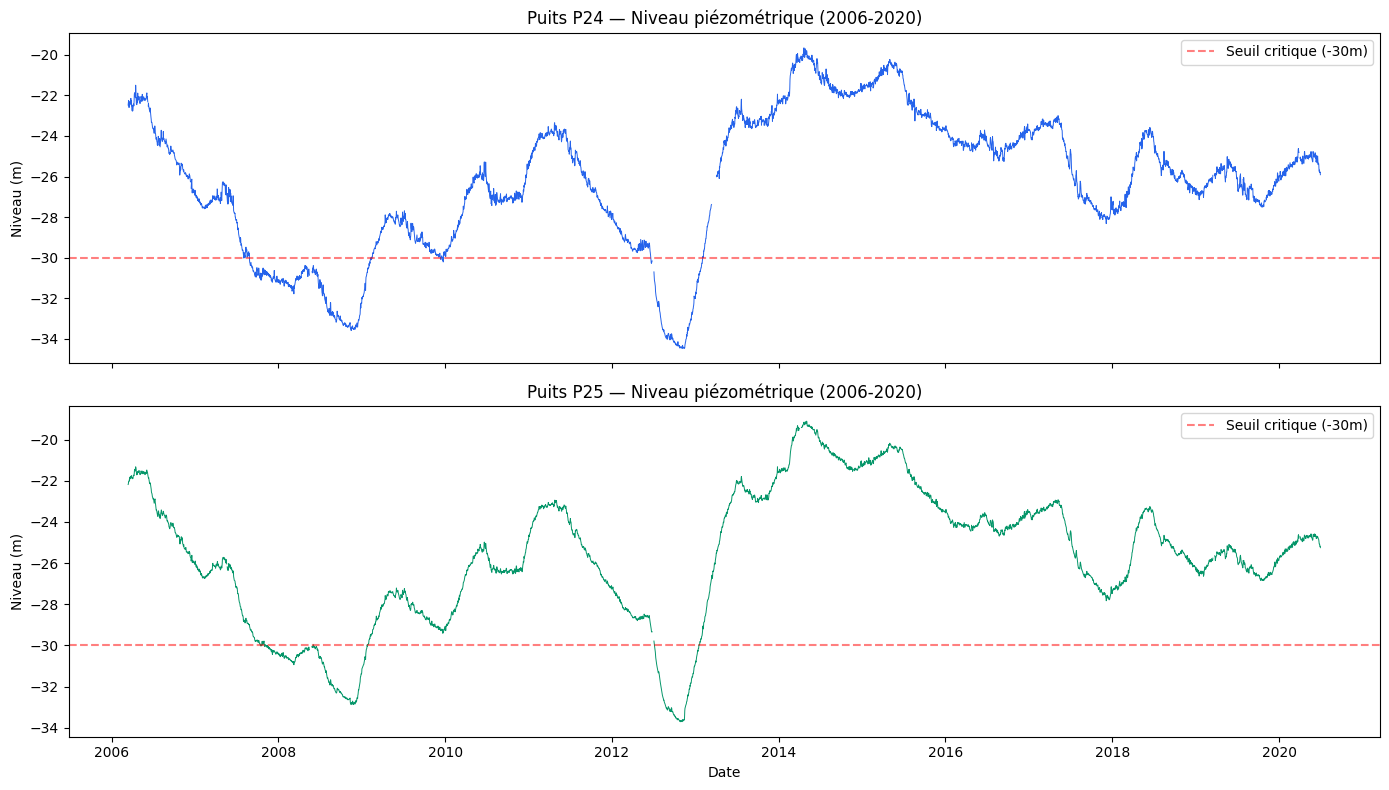

→ Figure sauvegardée dans data/processed/


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Puits P24
axes[0].plot(df['Date'], df['Depth_to_Groundwater_P24'], 
             color='#2563EB', linewidth=0.7)
axes[0].set_ylabel('Niveau (m)')
axes[0].set_title('Puits P24 — Niveau piézométrique (2006-2020)')
axes[0].axhline(y=-30, color='red', linestyle='--', alpha=0.5, label='Seuil critique (-30m)')
axes[0].legend()

# Puits P25
axes[1].plot(df['Date'], df['Depth_to_Groundwater_P25'], 
             color='#059669', linewidth=0.7)
axes[1].set_ylabel('Niveau (m)')
axes[1].set_title('Puits P25 — Niveau piézométrique (2006-2020)')
axes[1].axhline(y=-30, color='red', linestyle='--', alpha=0.5, label='Seuil critique (-30m)')
axes[1].legend()

plt.xlabel('Date')
plt.tight_layout()
# plt.savefig('../data/processed/2_fig_niveaux_des_puits_au_fil_du_temps.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

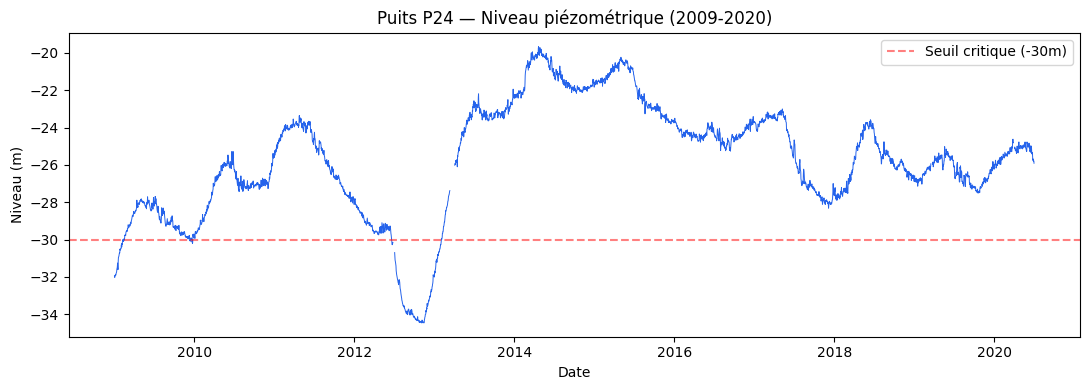

In [13]:
X = df[df['Date'] >= '2009-01-01']
fig, axes = plt.subplots(figsize=(11, 4), sharex=True)

# Puits P24
axes.plot(X['Date'], X['Depth_to_Groundwater_P24'], 
             color='#2563EB', linewidth=0.7)
axes.set_ylabel('Niveau (m)')
axes.set_title('Puits P24 — Niveau piézométrique (2009-2020)')
axes.axhline(y=-30, color='red', linestyle='--', alpha=0.5, label='Seuil critique (-30m)')
axes.legend()

# Puits P25
# axes[1].plot(X['Date'], X['Depth_to_Groundwater_P25'], 
#              color='#059669', linewidth=0.7)
# axes[1].set_ylabel('Niveau (m)')
# axes[1].set_title('Puits P25 — Niveau piézométrique (2006-2020)')
# axes[1].axhline(y=-30, color='red', linestyle='--', alpha=0.5, label='Seuil critique (-30m)')
# axes[1].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.savefig('../data/processed/5.1_fig_niveaux_P24_2009_2020.png', dpi=150, bbox_inches='tight')
plt.show()


<!-- df = df[df['Date'] >= '2009-01-01'].copy() -->

## Étape 6b : Niveaux piézométriques avec indication des saisons

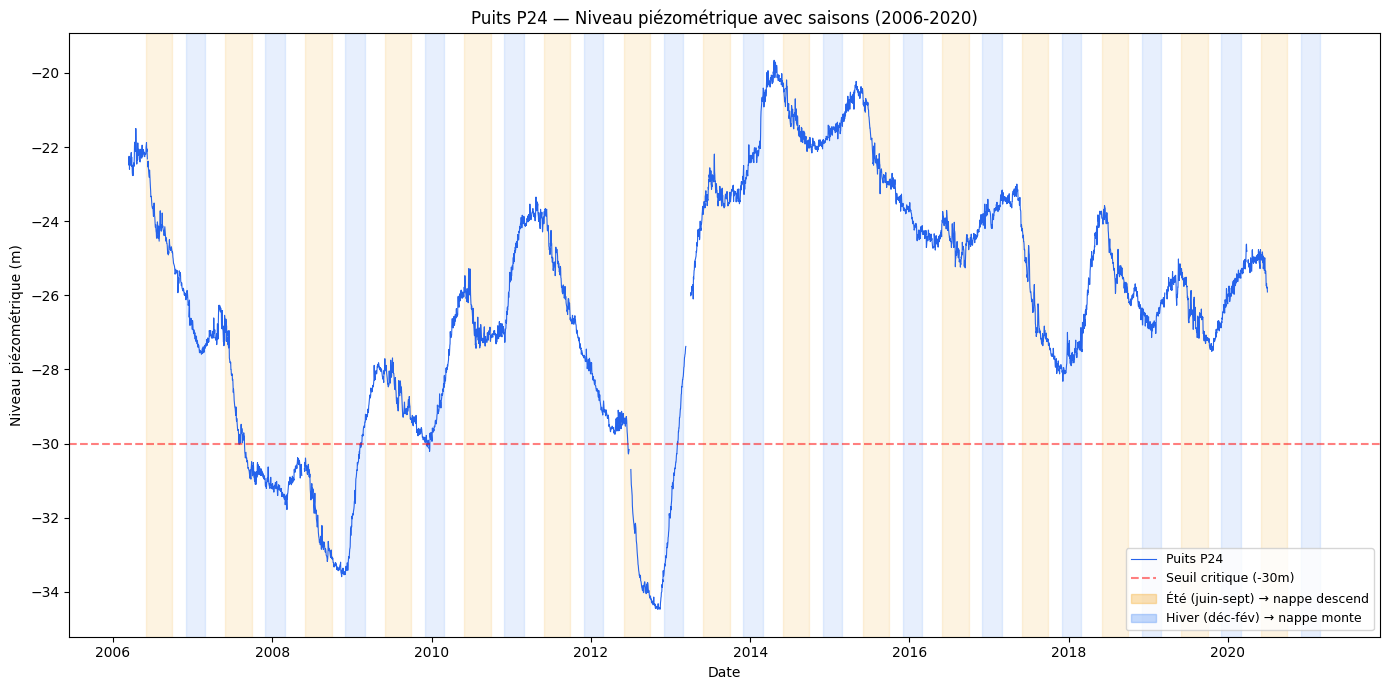

→ Figure sauvegardée dans data/processed/


In [6]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 7))

# Tracer le niveau P24
ax.plot(df['Date'], df['Depth_to_Groundwater_P24'], 
        color='#2563EB', linewidth=0.8, label='Puits P24')

# Ajouter les bandes de saisons (on colorie chaque été en orange clair)
for year in range(2006, 2021):
    # Été : juin à septembre (saison sèche = nappe descend)
    summer_start = pd.Timestamp(f'{year}-06-01')
    summer_end = pd.Timestamp(f'{year}-09-30')
    ax.axvspan(summer_start, summer_end, alpha=0.12, color='#F59E0B')
    
    # Hiver : décembre à février (saison humide = nappe monte)
    winter_start = pd.Timestamp(f'{year}-12-01')
    winter_end = pd.Timestamp(f'{year+1}-02-28')
    ax.axvspan(winter_start, winter_end, alpha=0.12, color='#3B82F6')

# Seuil critique
ax.axhline(y=-30, color='red', linestyle='--', alpha=0.5, label='Seuil critique (-30m)')

# Légende des saisons
summer_patch = mpatches.Patch(color='#F59E0B', alpha=0.3, label='Été (juin-sept) → nappe descend')
winter_patch = mpatches.Patch(color='#3B82F6', alpha=0.3, label='Hiver (déc-fév) → nappe monte')
ax.legend(handles=[ax.get_lines()[0], ax.get_lines()[1], summer_patch, winter_patch], 
          loc='lower right', fontsize=9)

ax.set_ylabel('Niveau piézométrique (m)')
ax.set_xlabel('Date')
ax.set_title('Puits P24 — Niveau piézométrique avec saisons (2006-2020)')

plt.tight_layout()
plt.savefig('../data/processed/3_fig_niveaux_des_puits_au_fil_du_temps_avec_saisons.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Étape 7 : Relation entre la pluie et le niveau piézométrique

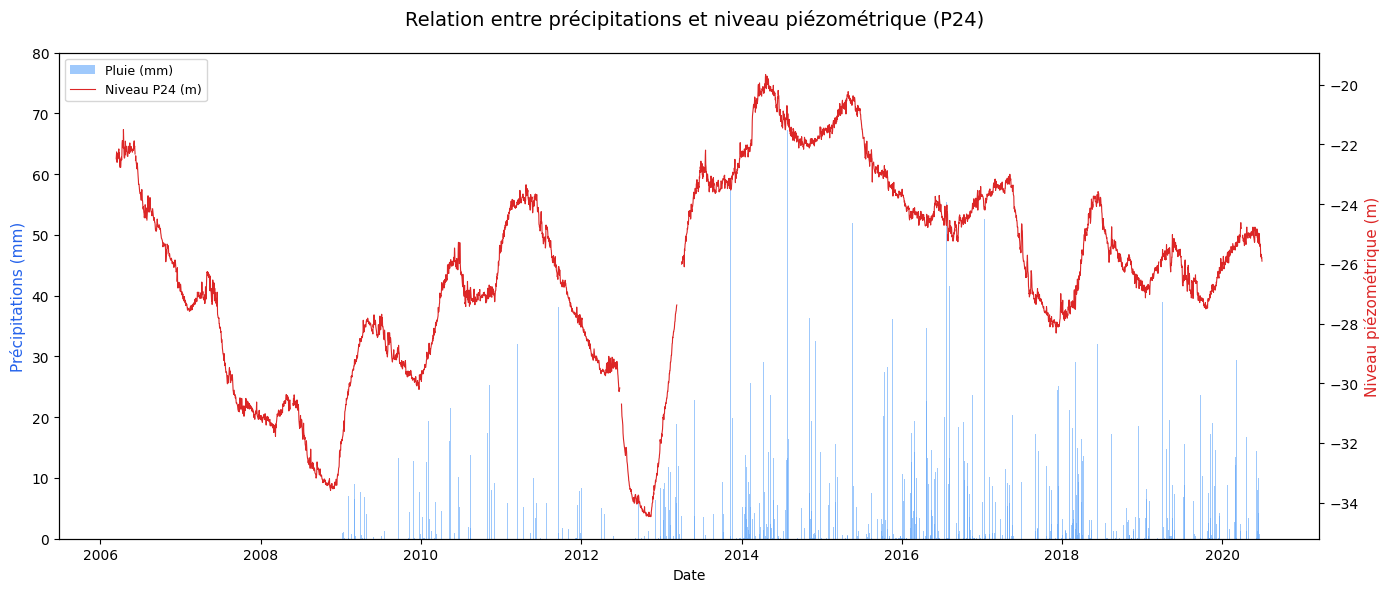

→ Figure sauvegardée dans data/processed/


In [7]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Axe gauche : pluie (barres)
ax1.bar(df['Date'], df['Rainfall_Bastia_Umbra'], 
        color='#60A5FA', alpha=0.6, width=2, label='Pluie (mm)')
ax1.set_ylabel('Précipitations (mm)', color='#2563EB', fontsize=11)
ax1.set_ylim(0, 80)

# Axe droit : niveau piézométrique (courbe)
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Depth_to_Groundwater_P24'], 
         color='#DC2626', linewidth=0.8, label='Niveau P24 (m)')
ax2.set_ylabel('Niveau piézométrique (m)', color='#DC2626', fontsize=11)

# Titre et mise en forme
fig.suptitle('Relation entre précipitations et niveau piézométrique (P24)', fontsize=14)
ax1.set_xlabel('Date')

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/4_fig_pluie_vs_niveau.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Étape 8 : Matrice de corrélation
 On va mesurer la relation mathématiquement avec les corrélations entre toutes les variables.

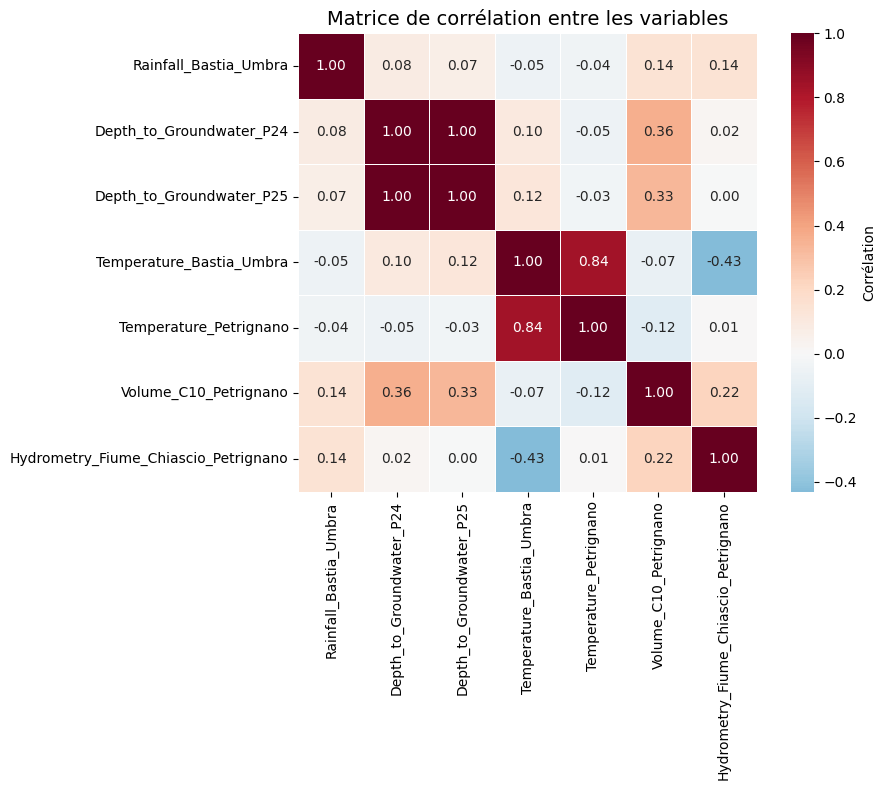

→ Figure sauvegardée dans data/processed/


In [8]:
import seaborn as sns

# Calculer la matrice de corrélation (seulement les colonnes numériques)
corr = df.drop(columns=['Date']).corr().round(2)

# Afficher sous forme de heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation entre les variables', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/5_fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée dans data/processed/")

## Étape 9 : Saisonnalité moyenne

On calcule le **niveau moyen par mois** sur les 14 ans.  

In [9]:
# Extraire le mois à partir de la date
df['Mois'] = df['Date'].dt.month

# Calculer la moyenne par mois
monthly_avg = df.groupby('Mois')['Depth_to_Groundwater_P24'].mean()

# Noms des mois
mois_noms = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
             'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']


plt.figure(figsize=(10, 5))
bars = plt.bar(range(1, 13), monthly_avg.values, color=colors, alpha=0.8, edgecolor='white')

plt.xlabel('Mois')
plt.ylabel('Niveau moyen (m)')
plt.title('Cycle annuel moyen du niveau piézométrique (P24)')
plt.xticks(range(1, 13), mois_noms)

# AJUSTER L'ÉCHELLE pour voir les variations
y_min = monthly_avg.min() - 0.5
y_max = monthly_avg.max() + 0.5
plt.ylim(y_min, y_max)

# Ajouter les valeurs au-dessus des barres
for bar, val in zip(bars, monthly_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.1, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Ligne horizontale à la moyenne globale
moyenne_globale = monthly_avg.mean()
plt.axhline(y=moyenne_globale, color='red', linestyle='--', alpha=0.5, 
            label=f'Moyenne annuelle : {moyenne_globale:.2f}m')
plt.legend()

plt.tight_layout()
plt.savefig('../data/processed/6_fig_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"→ Niveau le plus haut : {monthly_avg.idxmax()} → {monthly_avg.max():.2f}m")
print(f"→ Niveau le plus bas  : {monthly_avg.idxmin()} → {monthly_avg.min():.2f}m")
print(f"→ Amplitude saisonnière : {abs(monthly_avg.max() - monthly_avg.min()):.2f}m")

NameError: name 'colors' is not defined

<Figure size 1000x500 with 0 Axes>

## Conclusion de l'exploration des données

### Ce qu'on a appris

**Structure des données**
- 5223 lignes (jours) sur 8 colonnes
- Période : du 14/03/2006 au 30/06/2020 (14 ans)
- Format : séries temporelles journalières

**Qualité des données**
- Targets (P24, P25) : quasi complètes (1.1% et 0.7% de NaN)
- Pluie + Températures : bloc manquant 2006-2009 (~19.6% au total)
- Volume pompage : 3.8% de NaN, dispersés
- Stratégie de gestion : interpolation pour les NaN dispersés, à décider pour le bloc 2006-2009

**Comportement physique de la nappe**
- Plage : -19.66m (max) à -34.47m (min), amplitude totale 14.8m
- Saisonnalité claire : haut en mai, bas en novembre, amplitude saisonnière 2.46m
- Cycle long : 6 mois de descente, 6 mois de remontée
- Deux périodes critiques : 2008-2009 et 2012-2013 (sécheresses)

**Relations entre variables**
- P24 et P25 parfaitement corrélés (même nappe)
- Corrélations linéaires instantanées faibles avec pluie/température
- Cela confirme le besoin d'un modèle capturant les relations temporelles décalées